In [2]:
import glob, sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xarray as xr
import datetime as dt
from datetime import datetime, timedelta

from typing import Tuple, Optional, Union, List, Dict, Sequence, Any
from pathlib import Path
import zarr,json
from zarr.storage import ZipStore
# from netCDF4 import Dataset as NetCDF4Dataset
import numcodecs
from tqdm import tqdm
import gc

thismodule = sys.modules[__name__]

workdir = '/home/bfildier/analyses/FildierSaba2026/scripts'
DIR_UTIL = os.path.join(os.path.dirname(workdir),'util')
sys.path.insert(0,DIR_UTIL)

from file_data_loader import load_data, load_multiple_nc_files


In [3]:
cases_list_file = '/home/bfildier/analyses/FildierSaba2026/input/cases.csv'
cases_df = pd.read_csv(cases_list_file,sep=';')

In [4]:
data_path = '/homedata/osaba/clustering/satellite_data'
data_tb = xr.open_dataarray(os.path.join(data_path,'bt_mosaic.nc'))
data_selected = xr.open_dataarray(os.path.join(data_path,'QC_interp_selected.nc'))
data_final_labels = xr.open_dataarray(os.path.join(data_path,'CCS_final_labels.nc'))

In [5]:
! ls /homedata/osaba/clustering/satellite_data

bt_mosaic_g1.nc  CCS_final_labels.nc	CC_stats_indexed.nc
bt_mosaic.nc	 CCS_initial_labels.nc	QC_interp_selected.nc


In [6]:
data_final_labels

<xarray.DataArray 'labels_3d_algo_reconstitution' (time: 1968, latitude: 1501, longitude: 9000)>
[26585712000 values with dtype=int32]
Coordinates:
  * time       (time) datetime64[ns] 2016-08-01 ... 2016-09-10T23:30:00
  * latitude   (latitude) float32 -30.0 -29.96 -29.92 ... 29.92 29.96 30.0
  * longitude  (longitude) float32 -180.0 -180.0 -179.9 ... 179.8 179.9 179.9

In [7]:
data_tb

<xarray.DataArray 'Harmonized_irBT_mosaic' (time: 1968, latitude: 1501, longitude: 9000)>
[26585712000 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 2016-08-01 ... 2016-09-10T23:30:00
  * latitude   (latitude) float32 -30.0 -29.96 -29.92 ... 29.92 29.96 30.0
  * longitude  (longitude) float32 -180.0 -180.0 -179.9 ... 179.8 179.9 179.9

In [8]:
case = 'C19'
i_t = 30

# extract data associated to specific case
case_line = cases_df[cases_df['Old ID'] == case]

# select data between start and end 
# data_tb_case = data_tb.loc[dict(time=slice(case_line.Start.iloc[0],case_line.End.iloc[0]))]
data_tb_case = data_tb.loc[case_line.Start.iloc[0]:case_line.End.iloc[0],\
                           case_line.LatMin.iloc[0]:case_line.LatMax.iloc[0],\
                            case_line.LonMin.iloc[0]:case_line.LonMax.iloc[0]]

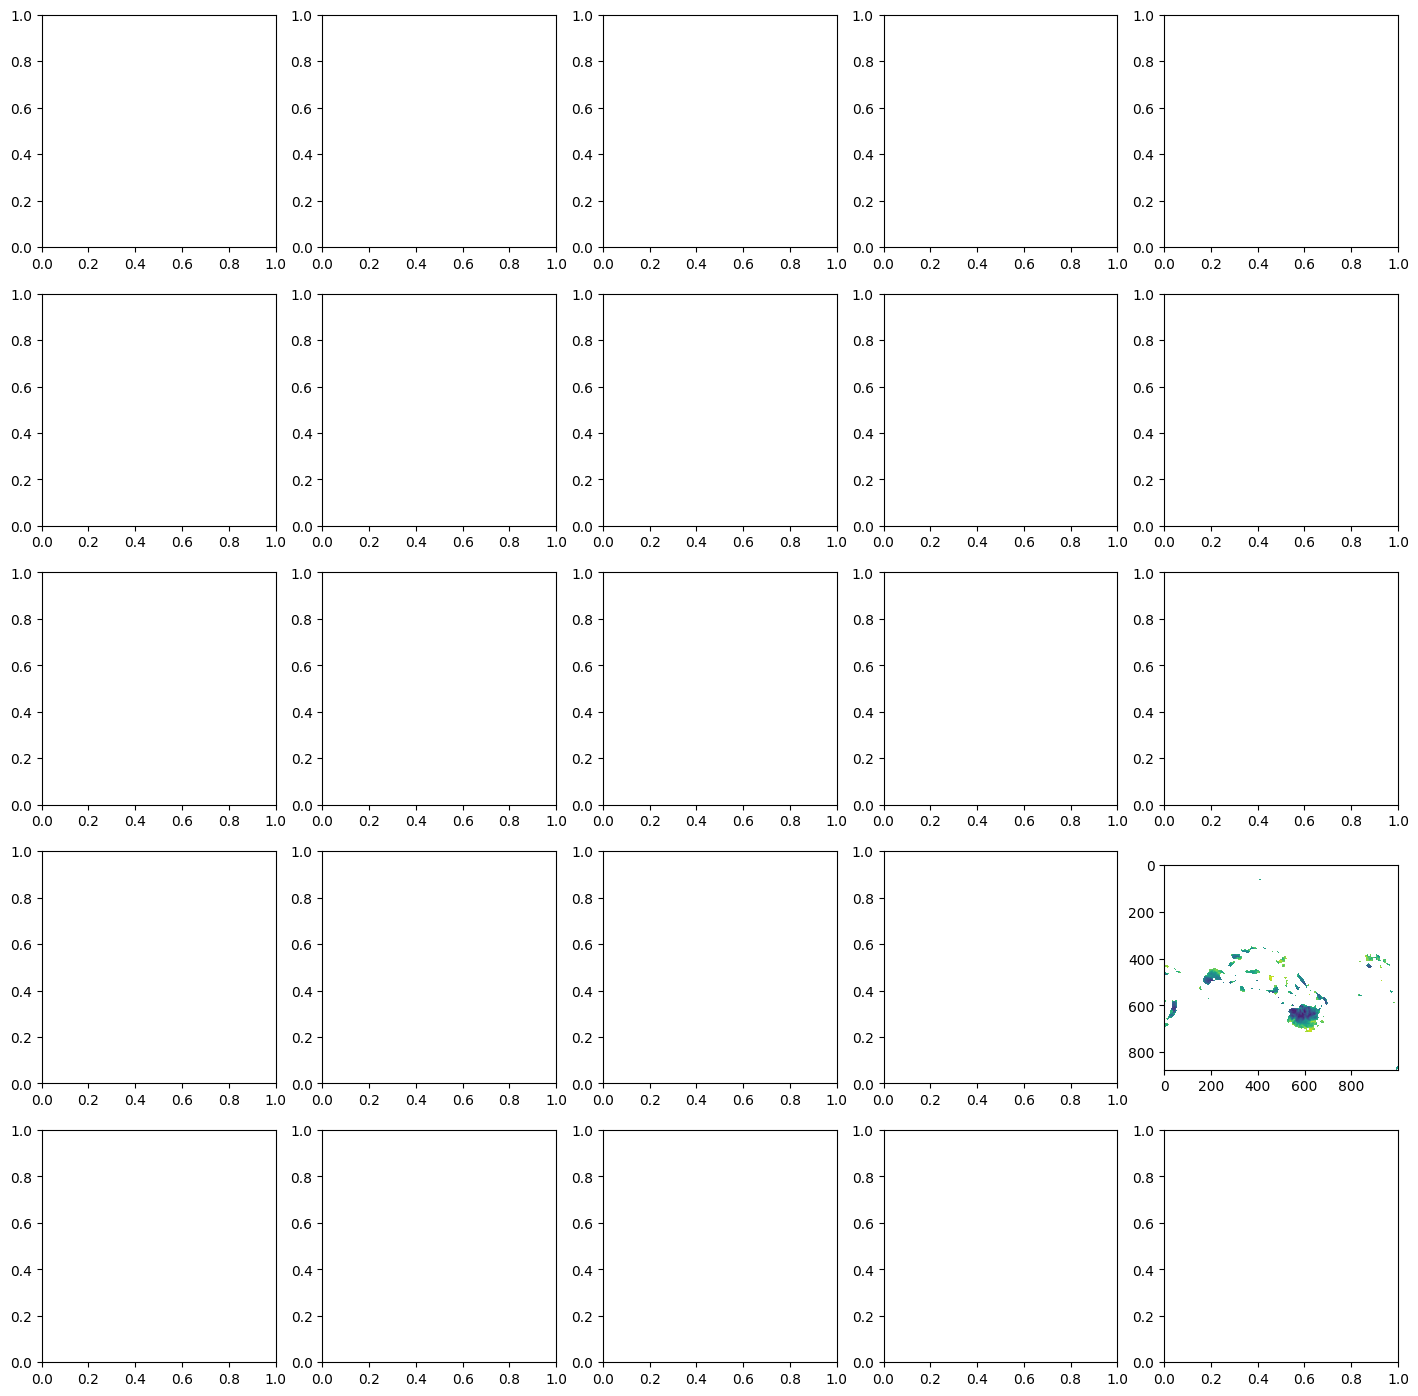

In [14]:
fig,axs = plt.subplots(nrows=5,ncols=5,figsize=(17.5,17.5))

for i_c in range(25):

    if i_c == 19:

        case = 'C%d'%i_c
        i_t = 120

        # extract data associated to specific case
        case_line = cases_df[cases_df['Old ID'] == case]

        # select data between start and end 
        # data_tb_case = data_tb.loc[dict(time=slice(case_line.Start.iloc[0],case_line.End.iloc[0]))]
        data_tb_case = data_tb.loc[case_line.Start.iloc[0]:case_line.End.iloc[0],\
                                case_line.LatMin.iloc[0]:case_line.LatMax.iloc[0],\
                                    case_line.LonMin.iloc[0]:case_line.LonMax.iloc[0]]

        ax = axs.flatten()[i_c]

        ax.imshow(data_tb_case[i_t])

In [9]:
import logging

# =============================================================================
# Logging
# =============================================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

DIR_DATA = '/bdd/GEOgrid_coldcloud'
DIR_TEMP = os.path.join(workdir,'temp')

# mapping satellite -> (sous-dossier, préfixe fichier)
SAT_MAP = {
    "HIMAWARI": ("HIMAWARI+1407", "GEO_L1C-HIMA08"),
    "GOES-W":   ("GOES-W-1350",   "GEO_L1C-GOES15"),
    "GOES-E":   ("GOES-E-0750",   "GEO_L1C-GOES13"),
    "MSG":      ("MSG+0000",      "GEO_L1C-MSG3"),
    "IODC":     ("IODC_MFG+0570", "GEO_L1C-MET7"),
}

# mapping satellite -> métadonnées sortie
SAT_METADATA_MAP = {
    "HIMAWARI": {
        "satellite_name": "HIMAWARI",
        "geostationary_platform": "HIMA08",
    },
    "GOES-W": {
        "satellite_name": "GOES-W",
        "geostationary_platform": "GOES15",
    },
    "GOES-E": {
        "satellite_name": "GOES-E",
        "geostationary_platform": "GOES13",
    },
    "MSG": {
        "satellite_name": "MSG",
        "geostationary_platform": "MSG3",
    },
    "IODC": {
        "satellite_name": "IODC",
        "geostationary_platform": "MET7",
    },
}

show_coords = {
    "C1":("2016-06-14T21:00",7.5,-150),
    "C2":("2016-06-19T00:00",7.5,-150),
    "C3":("2016-06-24T22:00",7.5,-145),
    "C5":("2016-06-24T23:00",10,-160),
    "C6":("2016-09-10T14:00",12.5,-165),
    "C7":("2016-06-06T21:30",9,-125),
    "C8":("2016-06-27T12:00",10,-115),
    "C9":("2016-06-04T02:00",5,20),
    "C10":("2016-07-01T19:30",10,20),
    "C11":("2016-07-23T03:30",7.5,20),
    "C12":("2016-07-05T15:00",5.0,20),
    "C13":("2016-07-17T16:00",2.5,22),
    "C14":("2016-06-09T21:00",10,0),
    "C15":("2016-08-06T20:30",5.0,25.0),
    "C16":("2016-08-25T07:00",5.0,20.0), # ou {"2026-08-24T05:00",5.0,20} en opposition de phase
    "C17":("2016-07-06T07:00",20,130),
    "C18":("2016-08-05T23:00",25,150),
    "C19":("2016-08-14T00:30",20,145),
    "C21":("2016-01-11T12:00",-5.0,-65),
    "C22":("2016-01-15T00:15",-10.0,-65),
    "C23":("2016-01-19T08:15",-12.0,-70),
    "C24":("2016-02-29T06:30",-5.0,-70),
    "C25":("2016-04-01T21:15",-5.0,-50),
    "C26":("2016-04-18T21:00",-5.0,-60),
    "C27":("2016-04-21T13:00",-5.0,-65),
}

delta_lat = 40
delta_lon = 40

In [10]:
def _clean_case_id(value) -> str:
    """Normalise l'ID de cas pour éviter les '1.0' si le CSV a été lu en float."""
    case_id = str(value).strip()
    if case_id.endswith(".0"):
        case_id = case_id[:-2]
    return case_id

def day_iter(start_dt, end_dt):
    cur = start_dt.date()
    endd = end_dt.date()
    one = timedelta(days=1)
    while cur <= endd:
        yield cur.year, cur.month, cur.day
        cur += one

def gather_files_for_case(data_dir, satellite, start_iso, end_iso):
    """Liste les fichiers pour le cas (par jour) pour limiter l'IO."""
    if satellite not in SAT_MAP:
        raise ValueError(
            f"Satellite inconnu: {satellite} (attendus: {list(SAT_MAP.keys())})"
        )

    subdir, prefix = SAT_MAP[satellite]
    start = datetime.fromisoformat(start_iso)
    end = datetime.fromisoformat(end_iso)

    files = []
    for y, m, d in day_iter(start, end):
        pat = os.path.join(
            data_dir,
            subdir,
            f"{y}",
            f"{y}_{m:02d}_{d:02d}*",
            f"{prefix}_{y}*.nc"
        )
        files.extend(glob.glob(pat))
        print(pat)

    return sorted(set(files))

def crop_spatial(
    da3d: xr.DataArray,
    lat_min: float,
    lat_max: float,
    lon_min: float,
    lon_max: float
) -> xr.DataArray:
    """
    Recadre (time, latitude, longitude) au bbox fourni.
    - Gère latitudes croissantes ou décroissantes
    - Gère longitudes en domaine [-180,180) ou [0,360)
    - Gère le franchissement de la ligne de changement de date
    """
    la0, la1 = (lat_min, lat_max) if lat_min <= lat_max else (lat_max, lat_min)
    lat_vals = da3d["latitude"].values
    lat_asc = bool(lat_vals[0] <= lat_vals[-1])

    if lat_asc:
        da3d = da3d.sel(latitude=slice(la0, la1))
    else:
        da3d = da3d.sel(latitude=slice(la1, la0))

    if not np.all(np.diff(da3d["longitude"].values) >= 0):
        da3d = da3d.sortby("longitude")

    lon_vals = da3d["longitude"].values
    domain = _infer_lon_domain(lon_vals)
    dom_min, dom_max = (0.0, 360.0) if domain == "360" else (-180.0, 180.0)

    lo0 = _to_domain(lon_min, domain)
    lo1 = _to_domain(lon_max, domain)

    if lo0 <= lo1:
        da_cut = da3d.sel(longitude=slice(lo0, lo1))
    else:
        part1 = da3d.sel(longitude=slice(lo0, dom_max))
        part2 = da3d.sel(longitude=slice(dom_min, lo1))
        da_cut = xr.concat([part1, part2], dim="longitude")
        da_cut = da_cut.sortby("longitude")

    return da_cut

In [ ]:
data_cases = {}
times_cases = {}
lats_cases = {}
lons_cases = {}

for _, row in cases_df.iterrows():
    case_id = _clean_case_id(row["Old ID"])

    print("--------------------------------------------------")
    print("|     Case %s                                    |"%case_id)
    print("--------------------------------------------------")

    sat = str(row["Satellite"]).strip()
    start = str(row["Start"]).strip()
    end = str(row["End"]).strip()
    lonmin = float(row["LonMin"])
    lonmax = float(row["LonMax"])
    latmin = float(row["LatMin"])
    latmax = float(row["LatMax"])

    # Get files for case
    files = gather_files_for_case(DIR_DATA, sat, start, end)
    if not files:
        logger.warning(
            "Aucun fichier trouvé pour %s → on passe au cas suivant.",
            case_id
        )
        continue

    logger.info("Fichiers: %d (ex: %s ...)", len(files), os.path.basename(files[0]))

    # -----------------------------------------------------------------
    # 1) Chargement
    # -----------------------------------------------------------------
    data1, times1, lats, lons = load_data(
        file_path=files,
        var_name="Harmonized_irBT",
        output_var_name="Harmonized_irBT",
        source_kind="auto",
        olr_min=40.0,
        olr_max=500.0,
        time_source="auto",
        filename_time_step_seconds=7.5,
        time_origin="1970-01-01",
        read_chunks={"time": 20, "latitude": 215, "longitude": 393},
        zarr_store=os.path.join(DIR_TEMP,"case_%s.zip"%case_id), # Write "case_%s_interp.zip"%case_id if remove_blinking=True
        force_overwrite=False,
        block_size=50,
        gzip_level=2,
        lat_range=(latmin, latmax),
        bt_min=170.0,
        bt_max=245.0,
        remove_blinking=False # BF choice for local scrit
    )
    logger.info("Données chargées: %s", tuple(data1.shape))

    data_cases[case_id] = data1
    times_cases[case_id] = times1
    lats_cases[case_id] = lats
    lons_cases[case_id] = lons

    # # 1) Chargement des données (écrit dans root_out / "temp_store.nc")
    # data1, _, lats, lons = load_data(
    #     file_path           = fp,
    #     var_name            = args.var_name,
    #     read_chunks         = args.read_chunks,
    #     zarr_store          = str(root_out / "temp_store"),
    #     force_overwrite     = args.force_overwrite,
    #     block_size          = args.block_size,
    #     gzip_level          = args.gzip_level,
    #     lat_range           = args.lat_range,
    #     bt_max              = args.bt_max
    # )
    # logger.info(f"[{sat_name}] Données chargées, shape: {data1.shape}")
    

    

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

--------------------------------------------------
|     Case C1                                    |
--------------------------------------------------
time range: 2016-06-14T21:00 - 2016-06-14T21:00
lat range: -12.5 - 27.5
lon range: -170.0 - -130.0
/bdd/GEOgrid_coldcloud/GOES-W-1350/2016/2016_06_14*/GEO_L1C-GOES15_2016*.nc
180.0 255.0
New lon range: 190.0 - 230.0
<xarray.DataArray 'Harmonized_irBT' ()>
array(245.)
Coordinates:
    time     datetime64[ns] 2016-06-14


/home/bfildier/.local/lib/python3.8/site-packages/xarray/conventions.py:492: SerializationWarning: variable 'Harmonized_irBT' has multiple fill values {-99800, -999}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


NameError: name 'cmap' is not defined

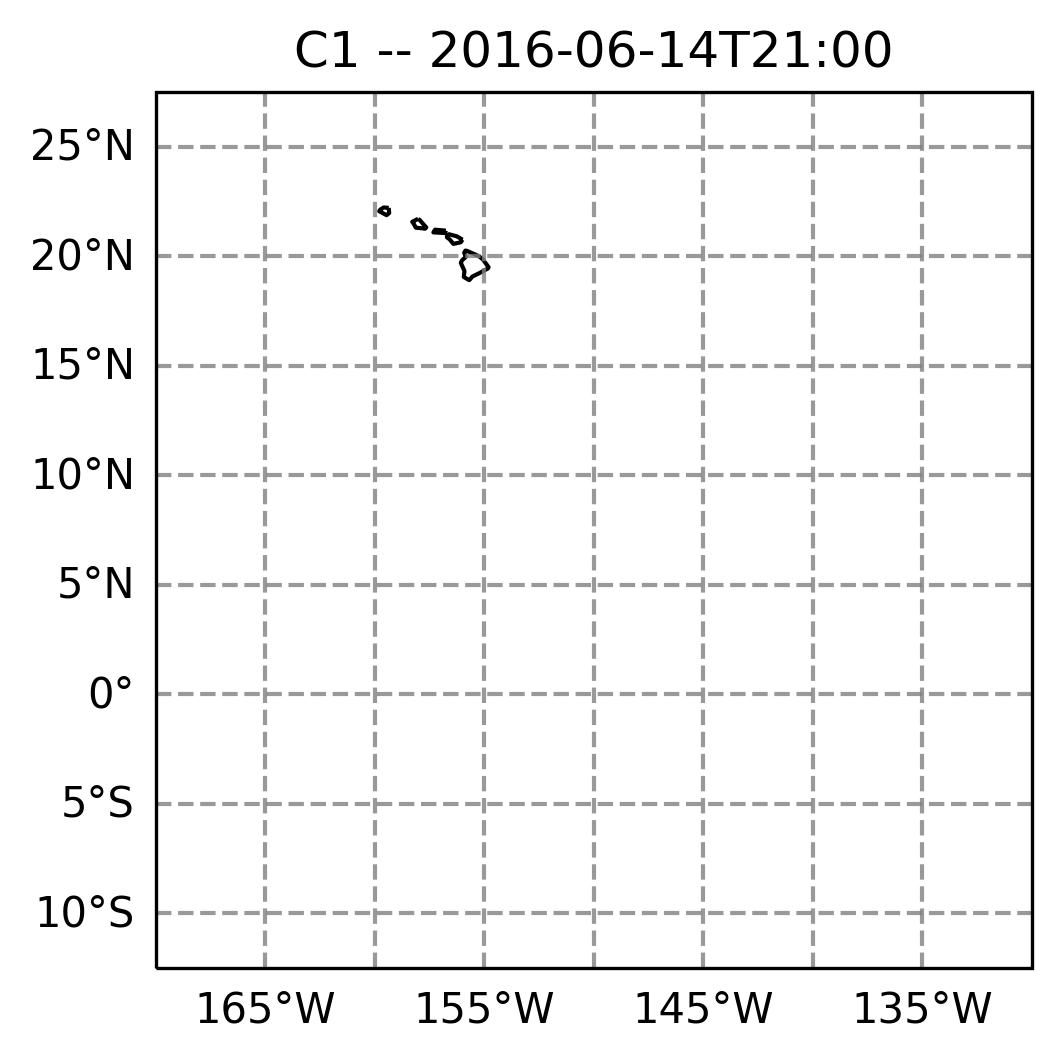

In [ ]:

for _, row in cases_df.iterrows():
    case_id = _clean_case_id(row["Old ID"])

    print("--------------------------------------------------")
    print("|     Case %s                                    |"%case_id)
    print("--------------------------------------------------")

    sat = str(row["Satellite"]).strip()
    start = show_coords[case_id][0]
    end = show_coords[case_id][0]
    latmin = show_coords[case_id][1]-delta_lat/2
    latmax = show_coords[case_id][1]+delta_lat/2
    lonmin = show_coords[case_id][2]-delta_lon/2
    lonmax = show_coords[case_id][2]+delta_lon/2
    print("time range: %s - %s"%(start,end))
    print("lat range: %s - %s"%(latmin,latmax))
    print("lon range: %s - %s"%(lonmin,lonmax))

    # Get files for case
    files = gather_files_for_case(DIR_DATA, sat, start, end)

    # Load data
    ds = xr.open_dataset(files[0])

    # Adjust longitude bounds

    lon_min_ds = float(ds.longitude.min())
    lon_max_ds = float(ds.longitude.max())
    print(lon_min_ds,lon_max_ds)

    def to_0_360(lon):
        return lon % 360

    if lon_min_ds >= 0 and lon_max_ds > 180:
        # Fichier en convention 0-360
        lonmin = to_0_360(lonmin)
        lonmax = to_0_360(lonmax)
        print("New lon range: %s - %s"%(lonmin,lonmax))
    
    # Select region

    ds_subset = ds.sel(
        latitude=slice(latmax, latmin),
        longitude=slice(lonmin, lonmax)
    ).Harmonized_irBT.squeeze()

    print(ds_subset.max())

    extent = [float(lonmin), float(lonmax), float(latmin), float(latmax)]
    central_lon = (lonmin+lonmax)/2

    coast_lw = 0.3
    border_lw = 1
    grid_lw = 0.5
    grid_alpha = 0.8
    # tick_labelsize = 

    # Plot

    fig = plt.figure(figsize=(4,4), dpi=300, facecolor="white")
    plt.subplots_adjust(bottom=0.15)  # un peu de marge pour la colorbar

    ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=central_lon))
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_facecolor("white")

    # traits fins
    ax.coastlines("110m", linewidth=coast_lw)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=border_lw)
    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                      linewidth=grid_lw, linestyle="-", color="gray", alpha=grid_alpha)
    gl.top_labels = gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True
    # gl.xlabel_style = gl.ylabel_style = {"size": tick_labelsize}
    ax.set_title("%s -- %s"%(case_id,start))#, fontsize=title_fontsize, pad=5)

    # 7) raster (Tb masquée au-dessus de 235 K)
    # latp = (lat[::-1] if flip_vertical else lat)[::downscale]
    # lonp = lon[::downscale]
    lon = ds_subset.longitude.values
    lat = ds_subset.latitude.values
    ny, nx = len(lat), len(lon)
    im = ax.imshow(
        np.ma.masked_all((ny, nx)), origin="lower", extent=extent,
        transform=ccrs.PlateCarree(), aspect="auto",
        interpolation="nearest", cmap=cmap, norm=norm_raw
    )


    break

In [25]:
print(ds_subset.latitude)

<xarray.DataArray 'latitude' (latitude: 0)>
array([], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 
Attributes:
    units:      degrees_north
    long_name:  latitude


1.0


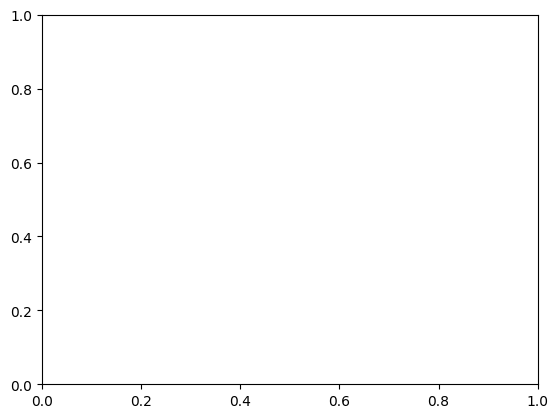

In [ ]:
case_id = 'C1'

fig,ax = plt.subplots()

show_time = show_coords[case_id][0]
delta_t = dt.timedelta(seconds=3600)
# t_0 = 

i_t = np.where(data_cases[case_id].time == np.datetime64(show_time))[0][0]

# tb = data_cases[case_id].sel(time=show_time)
tb = data_cases[case_id][i_t]
print(np.sum(np.isnan(tb.values))/tb.values.size)
# ax.imshow(tb)
